# Gradient Boosting Machines from Scratch 📈

## 📈 Theoretical Background
Gradient Boosting is an ensemble method that builds trees sequentially. Each new tree attempts to correct the errors (pseudo-residuals) of the existing ensemble.
- **Pseudo-residuals**: The negative gradient of the loss function.
- **Learning Rate**: Scales the contribution of each tree to prevent overfitting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

In [2]:

# Non-linear toy data
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, 100)

class SimpleGBM:
    def __init__(self, n_estimators=50, lr=0.1):
        self.n_estimators = n_estimators
        self.lr = lr
        self.trees = []
        self.initial_prediction = None
        
    def fit(self, X, y):
        self.initial_prediction = np.mean(y)
        prediction = np.full(y.shape, self.initial_prediction)
        
        for _ in range(self.n_estimators):
            residual = y - prediction
            tree = DecisionTreeRegressor(max_depth=2)
            tree.fit(X, residual)
            prediction += self.lr * tree.predict(X)
            self.trees.append(tree)
            
    def predict(self, X):
        prediction = np.full(X.shape[0], self.initial_prediction)
        for tree in self.trees:
            prediction += self.lr * tree.predict(X)
        return prediction

model = SimpleGBM(n_estimators=20, lr=0.2)
model.fit(X, y)
y_pred = model.predict(X)


### 📊 Visualization: Sequential Fitting

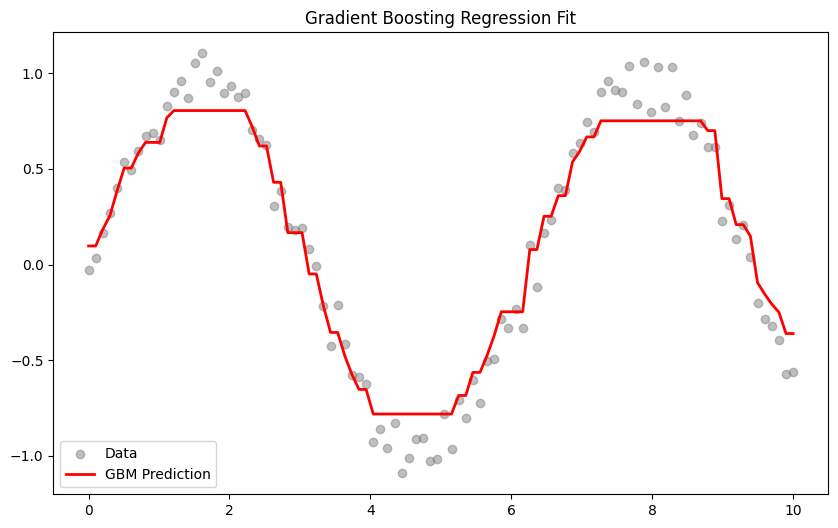

In [3]:

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Data')
plt.plot(X, y_pred, color='red', lw=2, label='GBM Prediction')
plt.title('Gradient Boosting Regression Fit')
plt.legend()
plt.show()
